# **🎯 Objetivo del Proyecto**

#### Autor= Juan Pablo Feijoo 

### **Análisis y Predicción de Éxito de Películas usando Machine Learning y Visualización Interactiva**

### **📝 Descripción**

Este análisis se basa en un dataset extraído de Kaggle que contiene información sobre películas, incluyendo datos como:
- **Presupuesto**
- **Géneros**
- **Actores principales**
- **Calificaciones de usuarios**
- **Ingresos de taquilla**

El dataset se limpiará y procesará para obtener insights sobre los factores que influyen en el éxito de una película.




### **📌 Preguntas Clave del Proyecto**
- ¿Qué factores influyen en el éxito de una película (calificaciones y recaudación)?
- ¿Se puede predecir la calificación promedio de una película antes de su estreno?
- ¿Cómo han cambiado las tendencias del cine a lo largo del tiempo?
- ¿Cuáles son los géneros más populares y rentables?
- ¿Existen patrones en las calificaciones de los usuarios según actores, directores o géneros?

## 🛠️ Carga de Librerías y Configuraciones Iniciales
Importamos las librerías necesarias para análisis de datos, visualización y machine learning.

In [1]:
# 📦 Manejo de datos
import pandas as pd
import numpy as np 

# 📊 Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# 🔄 Preprocesamiento de datos
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, TargetEncoder

# 🤖 Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

In [3]:
sns.set_style("darkgrid")

## 📥 Carga del Dataset
Leemos el archivo CSV y realizamos una inspección inicial para entender su estructura.

In [4]:
credits = pd.read_csv(r"C:\Users\Jfeij\OneDrive\Documentos\DATA ANALYST\DATA SCIENCE\PROYECTOS\Netflix_Analysis\data/credits.csv")
keywords = pd.read_csv(r"C:\Users\Jfeij\OneDrive\Documentos\DATA ANALYST\DATA SCIENCE\PROYECTOS\Netflix_Analysis\data/keywords.csv")
links = pd.read_csv(r"C:\Users\Jfeij\OneDrive\Documentos\DATA ANALYST\DATA SCIENCE\PROYECTOS\Netflix_Analysis\data/links.csv")
links_small = pd.read_csv(r"C:\Users\Jfeij\OneDrive\Documentos\DATA ANALYST\DATA SCIENCE\PROYECTOS\Netflix_Analysis\data/links_small.csv")
movies_metadata = pd.read_csv(r"C:\Users\Jfeij\OneDrive\Documentos\DATA ANALYST\DATA SCIENCE\PROYECTOS\Netflix_Analysis\data/movies_metadata.csv", low_memory=False)
ratings = pd.read_csv(r"C:\Users\Jfeij\OneDrive\Documentos\DATA ANALYST\DATA SCIENCE\PROYECTOS\Netflix_Analysis\data/ratings.csv")
ratings_small = pd.read_csv(r"C:\Users\Jfeij\OneDrive\Documentos\DATA ANALYST\DATA SCIENCE\PROYECTOS\Netflix_Analysis\data/ratings_small.csv")


**Merge para los datasets mas relevantes**

In [ ]:
def inspeccionar_df(df, nombre):
    print(f"\n📌 Información del dataset: {nombre}")
    print("-" * 40)
    print(f"🔹 Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
    print("\n🔹 Primeras filas:")
    display(df.head(3))  
    print("\n🔹 Valores nulos:")
    print(df.isnull().sum())
    print("\n🔹 Tipos de datos:")
    print(df.dtypes)

In [ ]:
for nombre, df in [("credits", credits), ("keywords", keywords), ("links", links), 
                   ("links_small", links_small), ("movies_metadata", movies_metadata), 
                   ("ratings", ratings), ("ratings_small", ratings_small)]:
    inspeccionar_df(df, nombre)

In [7]:
# Convertimos los IDs a enteros para evitar errores en el merge
movies_metadata["id"] = pd.to_numeric(movies_metadata["id"], errors="coerce")

# Unimos movies_metadata con credits y keywords usando "id"
movies_df = movies_metadata.merge(credits, on="id", how="left").merge(keywords, on="id", how="left")

# Revisamos la nueva tabla fusionada
inspeccionar_df(movies_df, "Movies con Créditos y Keywords")


📌 Información del dataset: Movies con Créditos y Keywords
----------------------------------------
🔹 Dimensiones: 46632 filas, 27 columnas

🔹 Primeras filas:


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew,keywords
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862.0,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844.0,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602.0,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."



🔹 Valores nulos:
adult                        0
belongs_to_collection    42055
budget                       0
genres                       0
homepage                 38620
id                           3
imdb_id                     17
original_language           11
original_title               0
overview                   995
popularity                   6
poster_path                399
production_companies         4
production_countries         4
release_date                88
revenue                      7
runtime                    271
spoken_languages             7
status                      89
tagline                  25849
title                        7
video                        7
vote_average                 7
vote_count                   7
cast                         4
crew                         4
keywords                     4
dtype: int64

🔹 Tipos de datos:
adult                     object
belongs_to_collection     object
budget                    object
genres        

In [8]:
# Convertimos "id" a entero eliminando nulos y convirtiendo a int
movies_df = movies_df.dropna(subset=["id"])
movies_df["id"] = movies_df["id"].astype(int)

# Revisamos valores nulos en el dataset
print(movies_df.isna().sum())

# Mostramos las primeras filas después de la limpieza
inspeccionar_df(movies_df, "Movies después de limpiar IDs y revisar nulos")

adult                        0
belongs_to_collection    42055
budget                       0
genres                       0
homepage                 38620
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   995
popularity                   4
poster_path                399
production_companies         4
production_countries         4
release_date                88
revenue                      4
runtime                    268
spoken_languages             4
status                      86
tagline                  25846
title                        4
video                        4
vote_average                 4
vote_count                   4
cast                         1
crew                         1
keywords                     1
dtype: int64

📌 Información del dataset: Movies después de limpiar IDs y revisar nulos
----------------------------------------
🔹 Dimensiones: 46629 filas, 27 colu

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,crew,keywords
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de...","[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."



🔹 Valores nulos:
adult                        0
belongs_to_collection    42055
budget                       0
genres                       0
homepage                 38620
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   995
popularity                   4
poster_path                399
production_companies         4
production_countries         4
release_date                88
revenue                      4
runtime                    268
spoken_languages             4
status                      86
tagline                  25846
title                        4
video                        4
vote_average                 4
vote_count                   4
cast                         1
crew                         1
keywords                     1
dtype: int64

🔹 Tipos de datos:
adult                     object
belongs_to_collection     object
budget                    object
genres        

## 📊 Análisis Exploratorio de Datos (EDA)
Visualizamos las distribuciones de las variables clave y exploramos correlaciones.

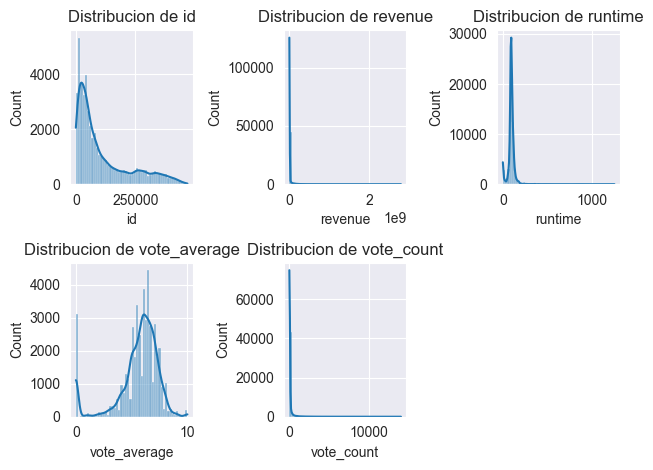

In [11]:
# Defino las columnas numericas relevantes
numeric_columns = ["id", "revenue", "runtime", "vote_average", "vote_count"]

for i , col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(movies_df[col].dropna(), bins = 50, kde= True)
    plt.title(f"Distribucion de {col}")
plt.tight_layout()
plt.show()   


In [12]:
print(movies_df[['budget', 'revenue', 'runtime', 'vote_average', 'vote_count']].describe().T)

                count          mean           std  min   25%   50%    75%  \
revenue       46625.0  1.102741e+07  6.380460e+07  0.0   0.0   0.0    0.0   
runtime       46361.0  9.408486e+01  3.845608e+01  0.0  85.0  95.0  107.0   
vote_average  46625.0  5.611608e+00  1.932311e+00  0.0   5.0   6.0    6.8   
vote_count    46625.0  1.081674e+02  4.864244e+02  0.0   3.0  10.0   34.0   

                       max  
revenue       2.787965e+09  
runtime       1.256000e+03  
vote_average  1.000000e+01  
vote_count    1.407500e+04  


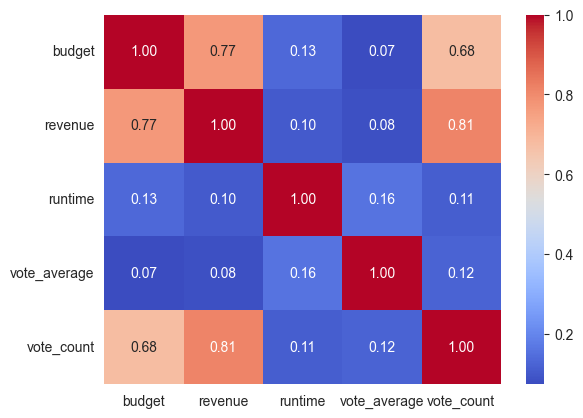

In [13]:
corr = movies_df [['budget', 'revenue', 'runtime', 'vote_average', 'vote_count']].corr()
sns.heatmap(corr, annot = True, cmap="coolwarm", fmt=".2f")
plt.show()

In [14]:
movies_df = movies_df.drop(columns=['belongs_to_collection', 'tagline', 'homepage', 'id', 'overview', 'status'])

In [16]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46629 entries, 0 to 46631
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 46629 non-null  object 
 1   budget                46629 non-null  object 
 2   genres                46629 non-null  object 
 3   imdb_id               46612 non-null  object 
 4   original_language     46618 non-null  object 
 5   original_title        46629 non-null  object 
 6   popularity            46625 non-null  object 
 7   poster_path           46230 non-null  object 
 8   production_companies  46625 non-null  object 
 9   production_countries  46625 non-null  object 
 10  release_date          46541 non-null  object 
 11  revenue               46625 non-null  float64
 12  runtime               46361 non-null  float64
 13  spoken_languages      46625 non-null  object 
 14  title                 46625 non-null  object 
 15  video                 46

In [17]:
movies_df.shape

(46629, 21)

In [18]:
movies_df = movies_df.reset_index(drop=True)

**Nuestro Target es "Revenue" por lo tanto realizo un boxplor para poder ver su distribucion**

<Axes: xlabel='revenue'>

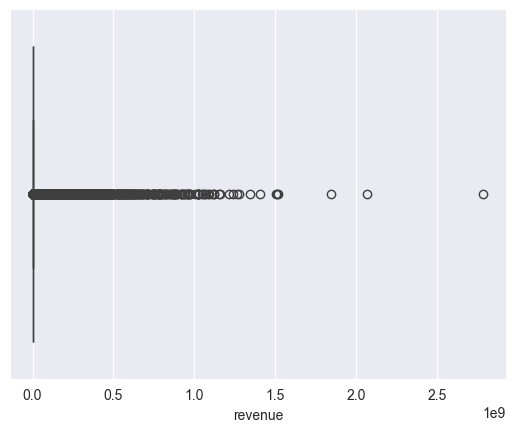

In [ ]:

sns.boxplot(x = movies_df["revenue"])

In [21]:
movies_df["log_revenue"] = np.log1p(movies_df["revenue"])

<Axes: xlabel='log_revenue', ylabel='Count'>

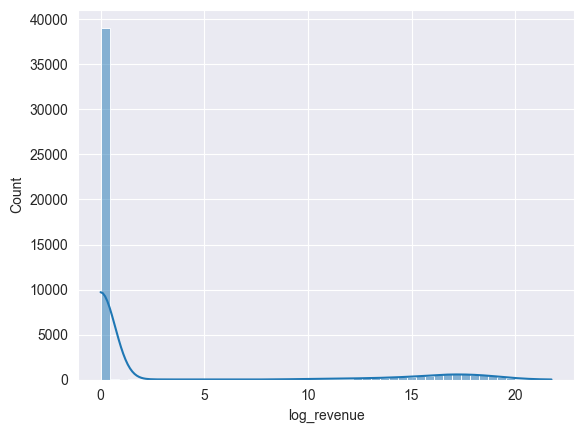

In [22]:
sns.histplot(movies_df["log_revenue"], kde=True, bins = 50)

## 🔄 Transformación Logarítmica de `revenue`
El revenue (ingreso) de las películas presenta una distribución altamente sesgada, con valores extremadamente grandes que pueden afectar negativamente el rendimiento de los modelos de Machine Learning. 

Para mitigar este sesgo, aplicamos una **transformación logarítmica** usando `np.log1p()`, lo que nos permite:
- **Reducir la asimetría** de los datos.
- **Mejorar la interpretación** y estabilidad del modelo.
- **Ajustar los valores extremos** sin perder información relevante.

Esto nos ayudará a entrenar un modelo más robusto y con mejores predicciones.

In [23]:
movies_df = movies_df[movies_df["revenue"] > 0]

In [24]:
movies_df.shape

(7537, 22)

In [25]:
movies_df = movies_df.reset_index(drop=True)

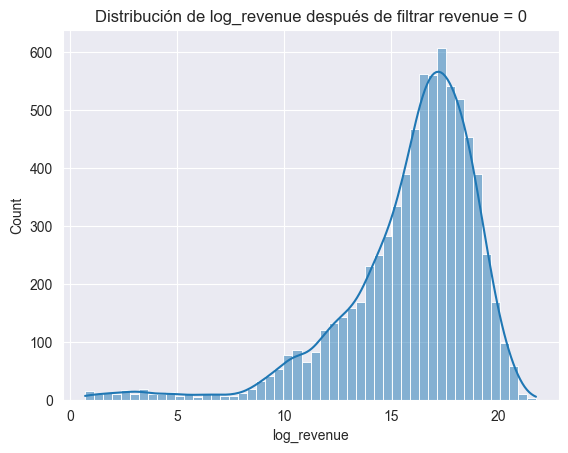

In [26]:
sns.histplot(movies_df["log_revenue"], kde=True, bins=50)
plt.xlabel("log_revenue")
plt.ylabel("Count")
plt.title("Distribución de log_revenue después de filtrar revenue = 0")
plt.show()

## 🧹 Limpieza y Preprocesamiento de Datos
Aplicamos transformaciones para limpiar los datos y prepararlos para el análisis.

In [27]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 7537 non-null   object 
 1   budget                7537 non-null   object 
 2   genres                7537 non-null   object 
 3   imdb_id               7537 non-null   object 
 4   original_language     7537 non-null   object 
 5   original_title        7537 non-null   object 
 6   popularity            7537 non-null   object 
 7   poster_path           7535 non-null   object 
 8   production_companies  7537 non-null   object 
 9   production_countries  7537 non-null   object 
 10  release_date          7536 non-null   object 
 11  revenue               7537 non-null   float64
 12  runtime               7531 non-null   float64
 13  spoken_languages      7537 non-null   object 
 14  title                 7537 non-null   object 
 15  video                

In [28]:
# Seleccionamos las columnas categóricas (de tipo 'object')
categorical_cols = movies_df.select_dtypes(include=['object']).columns

# Contamos los valores únicos en cada columna categórica
unique_values = movies_df[categorical_cols].nunique().sort_values(ascending=False)

# Mostramos el resultado
print(unique_values)

popularity              7401
imdb_id                 7398
poster_path             7396
crew                    7389
cast                    7365
original_title          7265
title                   7242
keywords                6497
production_companies    5549
release_date            4704
genres                  1521
spoken_languages         762
budget                   705
production_countries     655
original_language         44
video                      1
adult                      1
dtype: int64


In [29]:
# Lista de columnas a eliminar
cols_to_drop = ['imdb_id', 'poster_path', 'original_title', 'title', 'video', 'adult']

# Eliminamos las columnas
movies_df.drop(columns=cols_to_drop, inplace=True)


In [30]:
# Verificamos que las columnas fueron eliminadas
movies_df.head(3)

,budget,genres,original_language,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,vote_average,vote_count,cast,crew,keywords,log_revenue
0,30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",en,21.946943,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...",19.738573
1,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",en,17.015539,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1...",19.386893
2,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",en,3.859495,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...","[{'id': 818, 'name': 'based on novel'}, {'id':...",18.215526


In [31]:
# Convertimos release_date a datetime
movies_df['release_date'] = pd.to_datetime(movies_df['release_date'], errors='coerce')

In [32]:
# Extraemos solo el año
movies_df['release_year'] = movies_df['release_date'].dt.year


In [33]:
# Eliminamos la columna original
movies_df.drop(columns=['release_date'], inplace=True)

## 🔄 Transformación de Columnas Categóricas en Listas (`genre`, `production_companies`, etc.)

En el dataset, algunas columnas como **`genre`**, **`production_companies`**, **`original_language`**, **`production_countries`**, **`cast`**, **`keywords`** y **`crew`** estaban representadas como diccionarios en formato de texto (JSON-like). Para poder analizarlas correctamente, realizamos los siguientes pasos:

### 1️⃣ **Conversión de Diccionarios a Listas**  
Usamos la función `ast.literal_eval()` para convertir las cadenas de texto en estructuras de listas, permitiéndonos acceder a los valores individuales.

### 2️⃣ **Extracción de los Valores Relevantes**  
- En `genre`, `production_companies`, `production_countries`, `cast`, `keywords` y `crew`, extraímos los nombres principales en lugar de trabajar con IDs o estructuras anidadas.
- Para `original_language`, mantuvimos el idioma original como variable categórica.

### 3️⃣ **Selección del Top N para Cada Categoría**  
Dado que estas variables pueden tener una gran cantidad de valores distintos, creamos una lista con los **N valores más frecuentes** en cada columna.  
Luego, convertimos las variables en **dummies (one-hot encoding)** solo para los valores más representativos, evitando un número excesivo de columnas y reduciendo la dimensionalidad.

### 🎯 **Beneficios de esta Transformación**  
✅ **Mejor interpretación** de las variables.  
✅ **Reducción de dimensionalidad**, manteniendo solo las categorías más importantes.  
✅ **Mayor eficiencia en el modelo**, evitando columnas de baja frecuencia que aportarían poco valor.  

Estas transformaciones permiten capturar la información clave sin introducir ruido innecesario en el dataset.

📌 **Procesar genres**

In [34]:
 movies_df['genres'] = movies_df['genres'].fillna("[]").apply(ast.literal_eval)

In [35]:
movies_df['genres_list'] = movies_df['genres'].apply(lambda x: [d["name"] for d in x])


In [36]:
movies_df["main_genre"] = movies_df["genres_list"].apply(lambda x: x[0] if x else "Uknown")

In [37]:
print(movies_df[["genres","genres_list","main_genre"]].head())

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
3                     [{'id': 35, 'name': 'Comedy'}]   
4  [{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...   

                        genres_list main_genre  
0       [Animation, Comedy, Family]  Animation  
1      [Adventure, Fantasy, Family]  Adventure  
2          [Comedy, Drama, Romance]     Comedy  
3                          [Comedy]     Comedy  
4  [Action, Crime, Drama, Thriller]     Action  


In [38]:
movies_df.drop(columns= ["genres", "genres_list"], inplace= True)

In [39]:
print(movies_df["main_genre"].value_counts())

main_genre
Drama              1974
Comedy             1592
Action             1208
Adventure           504
Horror              405
Crime               342
Thriller            264
Documentary         192
Animation           189
Fantasy             184
Romance             180
Science Fiction     116
Mystery              92
Family               80
War                  52
Music                49
Western              44
History              40
Uknown               23
Foreign               6
TV Movie              1
Name: count, dtype: int64


In [ ]:
# Definir el umbral mínimo de frecuencia para conservar un género
threshold = 100  

# Identificar géneros con menos de 'threshold' apariciones
genres_to_replace = movies_df["main_genre"].value_counts()
genres_to_replace = genres_to_replace[genres_to_replace < threshold].index.tolist()

# Reemplazar esos géneros por "Other"
movies_df["main_genre"] = movies_df["main_genre"].apply(lambda x: "Other" if x in genres_to_replace else x)

In [41]:
# Aplicar One-Hot Encoding
movies_df = pd.get_dummies(movies_df, columns=["main_genre"], prefix="genre")

In [42]:
movies_df.head()

,budget,original_language,popularity,production_companies,production_countries,revenue,runtime,spoken_languages,vote_average,vote_count,cast,crew,keywords,log_revenue,release_year,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Horror,genre_Other,genre_Romance,genre_Science Fiction,genre_Thriller
0,30000000,en,21.946943,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...",19.738573,1995.0,False,False,True,False,False,False,False,False,False,False,False,False,False
1,65000000,en,17.015539,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1...",19.386893,1995.0,False,True,False,False,False,False,False,False,False,False,False,False,False
2,16000000,en,3.859495,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...","[{'id': 818, 'name': 'based on novel'}, {'id':...",18.215526,1995.0,False,False,False,True,False,False,False,False,False,False,False,False,False
3,0,en,8.387519,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...",18.153832,1995.0,False,False,False,True,False,False,False,False,False,False,False,False,False
4,60000000,en,17.924927,"[{'name': 'Regency Enterprises', 'id': 508}, {...","[{'iso_3166_1': 'US', 'name': 'United States o...",187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",7.7,1886.0,"[{'cast_id': 25, 'character': 'Lt. Vincent Han...","[{'credit_id': '52fe4292c3a36847f802916d', 'de...","[{'id': 642, 'name': 'robbery'}, {'id': 703, '...",19.048952,1995.0,True,False,False,False,False,False,False,False,False,False,False,False,False


📌 **Procesar production_companies**

In [43]:
# Convertir strings en listas si es necesario
movies_df["production_companies"] = movies_df["production_companies"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Extraer nombres de las compañías de producción
movies_df["production_companies"] = movies_df["production_companies"].apply(lambda x: [d["name"] for d in x] if isinstance(x, list) else [])

In [44]:
movies_df["production_company"] = movies_df["production_companies"].apply(lambda x: x[0] if len(x) > 0 else "Unknown")

In [45]:
movies_df.drop(columns=["production_companies"], inplace=True)

In [46]:
movies_df.head(5)

,budget,original_language,popularity,production_countries,revenue,runtime,spoken_languages,vote_average,vote_count,cast,crew,keywords,log_revenue,release_year,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Horror,genre_Other,genre_Romance,genre_Science Fiction,genre_Thriller,production_company
0,30000000,en,21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...",19.738573,1995.0,False,False,True,False,False,False,False,False,False,False,False,False,False,Pixar Animation Studios
1,65000000,en,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1...",19.386893,1995.0,False,True,False,False,False,False,False,False,False,False,False,False,False,TriStar Pictures
2,16000000,en,3.859495,"[{'iso_3166_1': 'US', 'name': 'United States o...",81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...","[{'id': 818, 'name': 'based on novel'}, {'id':...",18.215526,1995.0,False,False,False,True,False,False,False,False,False,False,False,False,False,Twentieth Century Fox Film Corporation
3,0,en,8.387519,"[{'iso_3166_1': 'US', 'name': 'United States o...",76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...",18.153832,1995.0,False,False,False,True,False,False,False,False,False,False,False,False,False,Sandollar Productions
4,60000000,en,17.924927,"[{'iso_3166_1': 'US', 'name': 'United States o...",187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",7.7,1886.0,"[{'cast_id': 25, 'character': 'Lt. Vincent Han...","[{'credit_id': '52fe4292c3a36847f802916d', 'de...","[{'id': 642, 'name': 'robbery'}, {'id': 703, '...",19.048952,1995.0,True,False,False,False,False,False,False,False,False,False,False,False,False,Regency Enterprises


📌 **Procesar original_language**

Cambiamos el enfoque ya que nuestro objetivo es predecir los ingresos de las peliculas

In [47]:
movies_df.drop(columns=['spoken_languages'], inplace=True)

In [48]:
movies_df.head()

,budget,original_language,popularity,production_countries,revenue,runtime,vote_average,vote_count,cast,crew,keywords,log_revenue,release_year,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Horror,genre_Other,genre_Romance,genre_Science Fiction,genre_Thriller,production_company
0,30000000,en,21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",373554033.0,81.0,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...",19.738573,1995.0,False,False,True,False,False,False,False,False,False,False,False,False,False,Pixar Animation Studios
1,65000000,en,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",262797249.0,104.0,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1...",19.386893,1995.0,False,True,False,False,False,False,False,False,False,False,False,False,False,TriStar Pictures
2,16000000,en,3.859495,"[{'iso_3166_1': 'US', 'name': 'United States o...",81452156.0,127.0,6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...","[{'id': 818, 'name': 'based on novel'}, {'id':...",18.215526,1995.0,False,False,False,True,False,False,False,False,False,False,False,False,False,Twentieth Century Fox Film Corporation
3,0,en,8.387519,"[{'iso_3166_1': 'US', 'name': 'United States o...",76578911.0,106.0,5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...",18.153832,1995.0,False,False,False,True,False,False,False,False,False,False,False,False,False,Sandollar Productions
4,60000000,en,17.924927,"[{'iso_3166_1': 'US', 'name': 'United States o...",187436818.0,170.0,7.7,1886.0,"[{'cast_id': 25, 'character': 'Lt. Vincent Han...","[{'credit_id': '52fe4292c3a36847f802916d', 'de...","[{'id': 642, 'name': 'robbery'}, {'id': 703, '...",19.048952,1995.0,True,False,False,False,False,False,False,False,False,False,False,False,False,Regency Enterprises


In [49]:
def categorize_language(lang):
    european_langs = {"fr", "es", "de", "it", "pt", "nl", "ru"}
    asian_langs = {"zh", "ja", "ko", "hi", "th"}
    
    if lang == "en":
        return "English"
    elif lang == "european_langs":
        return "European Languages"
    elif lang == asian_langs:
        return "Asian Languages"
    else:
        return "Other Languages"

In [50]:
movies_df["language_group"] = movies_df["original_language"].apply(categorize_language)
movies_df = pd.get_dummies(movies_df, columns=["language_group"], prefix="lang")

In [51]:
print(movies_df[['lang_English', 'lang_Other Languages']].sum())

lang_English            6428
lang_Other Languages    1109
dtype: int64


In [52]:
#Procedo a eliminar la columna "original_language"

movies_df.drop(columns=["original_language"], inplace= True)

In [53]:
movies_df.head()

,budget,popularity,production_countries,revenue,runtime,vote_average,vote_count,cast,crew,keywords,log_revenue,release_year,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Horror,genre_Other,genre_Romance,genre_Science Fiction,genre_Thriller,production_company,lang_English,lang_Other Languages
0,30000000,21.946943,"[{'iso_3166_1': 'US', 'name': 'United States o...",373554033.0,81.0,7.7,5415.0,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...",19.738573,1995.0,False,False,True,False,False,False,False,False,False,False,False,False,False,Pixar Animation Studios,True,False
1,65000000,17.015539,"[{'iso_3166_1': 'US', 'name': 'United States o...",262797249.0,104.0,6.9,2413.0,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1...",19.386893,1995.0,False,True,False,False,False,False,False,False,False,False,False,False,False,TriStar Pictures,True,False
2,16000000,3.859495,"[{'iso_3166_1': 'US', 'name': 'United States o...",81452156.0,127.0,6.1,34.0,"[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de...","[{'id': 818, 'name': 'based on novel'}, {'id':...",18.215526,1995.0,False,False,False,True,False,False,False,False,False,False,False,False,False,Twentieth Century Fox Film Corporation,True,False
3,0,8.387519,"[{'iso_3166_1': 'US', 'name': 'United States o...",76578911.0,106.0,5.7,173.0,"[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de...","[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...",18.153832,1995.0,False,False,False,True,False,False,False,False,False,False,False,False,False,Sandollar Productions,True,False
4,60000000,17.924927,"[{'iso_3166_1': 'US', 'name': 'United States o...",187436818.0,170.0,7.7,1886.0,"[{'cast_id': 25, 'character': 'Lt. Vincent Han...","[{'credit_id': '52fe4292c3a36847f802916d', 'de...","[{'id': 642, 'name': 'robbery'}, {'id': 703, '...",19.048952,1995.0,True,False,False,False,False,False,False,False,False,False,False,False,False,Regency Enterprises,True,False


📌 **Procesar production_countries**

In [54]:
movies_df["production_countries"] = movies_df["production_countries"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

#Extrae el primer pais de la lista
movies_df["main_country"] = movies_df["production_countries"]. apply(
    lambda x: x[0]["name"] if isinstance(x, list) and len(x) > 0 else "unknown"
)

In [55]:
print(movies_df["main_country"].value_counts())

main_country
United States of America    4545
United Kingdom               549
France                       375
Canada                       268
Germany                      225
                            ... 
Congo                          1
Mauritania                     1
Bosnia and Herzegovina         1
Palestinian Territory          1
Portugal                       1
Name: count, Length: 76, dtype: int64


In [56]:
min_threshold = 0.01 * len(movies_df)

# contar la frecuencia para cada pais

country_counts = movies_df["main_country"].value_counts()

top_countries = country_counts[country_counts >= min_threshold].index

#Crear variables dummies para los paises mas frecuentes
for country in top_countries:
    movies_df[f"country_{country.replace(' ', '_')}"] = (movies_df["main_country"] == country).astype(int)

# Creo otra columna de otros paises
movies_df["country_other"] = movies_df["main_country"].apply(lambda x: 1 if x not in top_countries else 0)

print(movies_df.filter(like="country_").sum())

    

country_United_States_of_America    4545
country_United_Kingdom               549
country_France                       375
country_Canada                       268
country_Germany                      225
country_India                        216
country_unknown                      156
country_Japan                        138
country_Australia                    125
country_Russia                       116
country_Spain                         85
country_Italy                         83
country_other                        656
dtype: int64


In [57]:
movies_df.drop(columns=["production_countries", "main_country"], inplace= True )

**Observamos la distribucion de peliculas por pais**

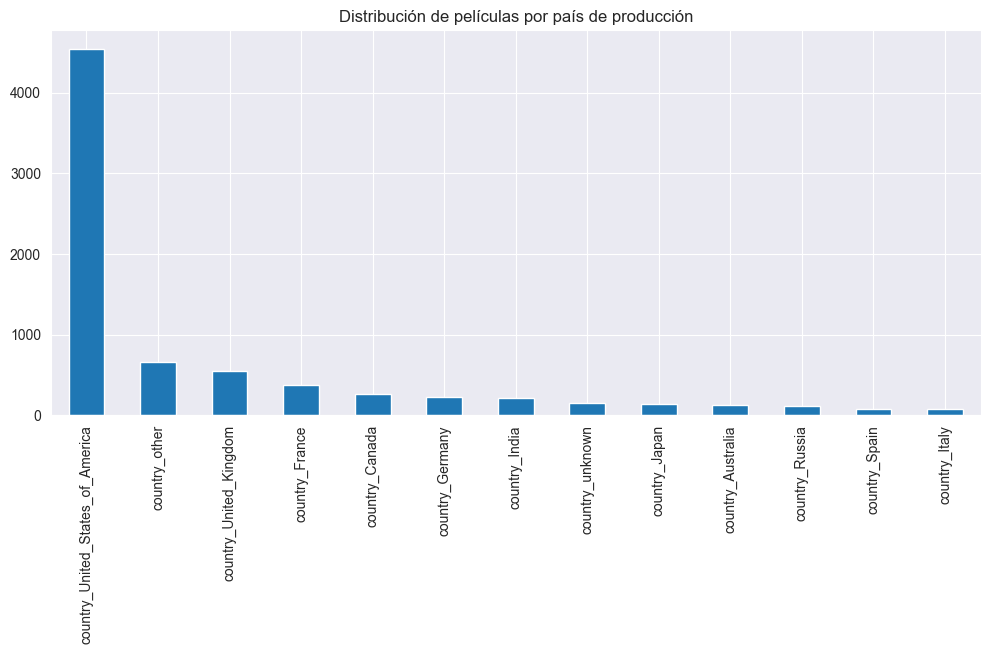

In [58]:
movies_df.filter(like="country_").sum().sort_values(ascending=False).plot(kind="bar", figsize=(12,5))
plt.title("Distribución de películas por país de producción")
plt.show()

📌 **Procesar Crew**

In [59]:
movies_df["crew"] = movies_df["crew"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x) 

In [60]:
movies_df["crew"].value_counts()

crew
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [61]:
movies_df["director"] = movies_df["crew"].apply(lambda x: next((d["name"] for d in x if d["job"]=="Director"), None))

In [62]:
movies_df["director"].head(10)

0      John Lasseter
1       Joe Johnston
2    Forest Whitaker
3      Charles Shyer
4       Michael Mann
5        Peter Hyams
6    Martin Campbell
7         Rob Reiner
8        Simon Wells
9       Oliver Stone
Name: director, dtype: object

In [63]:
print(len(movies_df["director"]))
print(len(movies_df["crew"]))

7537
7537


📌 **Procesar Cast**

In [64]:
movies_df["cast"] = movies_df["cast"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [65]:
movies_df["main_actors"] = movies_df["cast"].apply(lambda x:[d["name"] for d in x[:2]] if isinstance(x, list) else [])

In [66]:
movies_df["main_actors"].head(10)

0                    [Tom Hanks, Tim Allen]
1           [Robin Williams, Jonathan Hyde]
2         [Whitney Houston, Angela Bassett]
3              [Steve Martin, Diane Keaton]
4               [Al Pacino, Robert De Niro]
5    [Jean-Claude Van Damme, Powers Boothe]
6               [Pierce Brosnan, Sean Bean]
7         [Michael Douglas, Annette Bening]
8                [Kevin Bacon, Bob Hoskins]
9             [Anthony Hopkins, Joan Allen]
Name: main_actors, dtype: object

In [67]:
print(len(movies_df["main_actors"]))
print(len(movies_df["cast"]))

7537
7537


📌 **Procesar Keywords**

In [68]:
print(movies_df["keywords"].explode().nunique())


6497


In [69]:
movies_df.drop(columns=["cast", "crew","keywords"], inplace=True)


In [70]:
print(movies_df.info())
print(movies_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   budget                            7537 non-null   object 
 1   popularity                        7537 non-null   object 
 2   revenue                           7537 non-null   float64
 3   runtime                           7531 non-null   float64
 4   vote_average                      7537 non-null   float64
 5   vote_count                        7537 non-null   float64
 6   log_revenue                       7537 non-null   float64
 7   release_year                      7536 non-null   float64
 8   genre_Action                      7537 non-null   bool   
 9   genre_Adventure                   7537 non-null   bool   
 10  genre_Animation                   7537 non-null   bool   
 11  genre_Comedy                      7537 non-null   bool   
 12  genre_

## 🛠️ Manejo de Valores Nulos

En nuestro dataset, identificamos la presencia de valores nulos en varias columnas. Para evitar problemas en el análisis y modelado, aplicamos estrategias específicas para cada caso:

🔢 Columnas Numéricas
- Para columnas como runtime, utilizamos la mediana, ya que es menos sensible a valores extremos:

In [71]:
movies_df["runtime"].fillna(movies_df["runtime"].median(), inplace = True)

C:\Users\Jfeij\AppData\Local\Temp\ipykernel_2664\2316163920.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movies_df["runtime"].fillna(movies_df["runtime"].median(), inplace = True)


**Para release_year, utilizamos la moda (valor más frecuente), ya que los años de lanzamiento suelen repetirse:**

In [72]:
movies_df["release_year"].fillna(movies_df["release_year"].mode()[0], inplace = True)

C:\Users\Jfeij\AppData\Local\Temp\ipykernel_2664\1423578313.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movies_df["release_year"].fillna(movies_df["release_year"].mode()[0], inplace = True)


🔠 Columnas Categóricas
- Para columnas como director, donde el valor nulo no representa un error sino falta de información, reemplazamos los valores faltantes con "Unknown":

In [73]:
movies_df['director'].fillna('Unknown', inplace = True)

C:\Users\Jfeij\AppData\Local\Temp\ipykernel_2664\2297545716.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movies_df['director'].fillna('Unknown', inplace = True)


✅ 3️⃣ Verificación Final

In [74]:
print(movies_df.info())
print(movies_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   budget                            7537 non-null   object 
 1   popularity                        7537 non-null   object 
 2   revenue                           7537 non-null   float64
 3   runtime                           7537 non-null   float64
 4   vote_average                      7537 non-null   float64
 5   vote_count                        7537 non-null   float64
 6   log_revenue                       7537 non-null   float64
 7   release_year                      7537 non-null   float64
 8   genre_Action                      7537 non-null   bool   
 9   genre_Adventure                   7537 non-null   bool   
 10  genre_Animation                   7537 non-null   bool   
 11  genre_Comedy                      7537 non-null   bool   
 12  genre_

## 🔄 Tratamiento de Variables Categóricas

El dataset contiene varias columnas categóricas que deben ser transformadas para su uso en análisis y modelado. Aplicamos diferentes estrategias según el tipo de variable.


### 1️⃣ **Conversión de Variables Numéricas Almacenadas como Texto**
Algunas columnas, como `budget` y `popularity`, estaban almacenadas como texto en lugar de valores numéricos.  
Para corregir esto, utilizamos `pd.to_numeric()` con el parámetro `errors='coerce'` para convertirlas en valores numéricos y manejar posibles errores.


In [75]:
# Convertir budget y popularity a numérico
movies_df["budget"] = pd.to_numeric(movies_df["budget"], errors='coerce')
movies_df["popularity"] = pd.to_numeric(movies_df["popularity"], errors='coerce')

In [76]:
# Verificamos que ahora sean float
print(movies_df[["budget", "popularity"]].dtypes)

budget          int64
popularity    float64
dtype: object


In [77]:
print(movies_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   budget                            7537 non-null   int64  
 1   popularity                        7537 non-null   float64
 2   revenue                           7537 non-null   float64
 3   runtime                           7537 non-null   float64
 4   vote_average                      7537 non-null   float64
 5   vote_count                        7537 non-null   float64
 6   log_revenue                       7537 non-null   float64
 7   release_year                      7537 non-null   float64
 8   genre_Action                      7537 non-null   bool   
 9   genre_Adventure                   7537 non-null   bool   
 10  genre_Animation                   7537 non-null   bool   
 11  genre_Comedy                      7537 non-null   bool   
 12  genre_

In [78]:
print(movies_df["production_company"].value_counts())

production_company
Unknown                                   426
Paramount Pictures                        405
Universal Pictures                        402
Twentieth Century Fox Film Corporation    292
Columbia Pictures                         237
                                         ... 
Silent Hill DCP Inc.                        1
Vulcan Productions Inc.                     1
Film Finance Group                          1
Bergman Lustig productions                  1
Кинокомпания «Lunapark»                     1
Name: count, Length: 2004, dtype: int64


In [79]:
movies_df.drop(columns=["production_company"], inplace=True)

In [80]:
print(movies_df["director"].value_counts())

director
Steven Spielberg          30
Clint Eastwood            29
Woody Allen               27
Ridley Scott              23
Alfred Hitchcock          21
                          ..
Laurie Collyer             1
Jonas Frick                1
Preston A. Whitmore II     1
Bob Dolman                 1
Vladimir Shchegolkov       1
Name: count, Length: 3365, dtype: int64


In [81]:
movies_df.drop(columns=["director"], inplace=True)

In [82]:
print(movies_df["main_actors"].value_counts())

main_actors
[]                                           34
[Veronica Taylor, Rachael Lillis]            18
[Lisa Loven Kongsli, Johannes Bah Kuhnke]     8
[Juliette Binoche, Jean-Luc Vincent]          8
[Mark Strong, Antonio Banderas]               8
                                             ..
[Devon Sawa, Bridgette Wilson]                1
[Adam Sandler, Jackie Sandler]                1
[Leonor Watling, Rosario Flores]              1
[Michael Caine, Brendan Fraser]               1
[Vladimir Turchinsky, Dmitriy Dyuzhev]        1
Name: count, Length: 7077, dtype: int64


In [83]:
movies_df.drop(columns=["main_actors"], inplace=True)

In [84]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   budget                            7537 non-null   int64  
 1   popularity                        7537 non-null   float64
 2   revenue                           7537 non-null   float64
 3   runtime                           7537 non-null   float64
 4   vote_average                      7537 non-null   float64
 5   vote_count                        7537 non-null   float64
 6   log_revenue                       7537 non-null   float64
 7   release_year                      7537 non-null   float64
 8   genre_Action                      7537 non-null   bool   
 9   genre_Adventure                   7537 non-null   bool   
 10  genre_Animation                   7537 non-null   bool   
 11  genre_Comedy                      7537 non-null   bool   
 12  genre_

1️⃣ Distribución del presupuesto (budget)


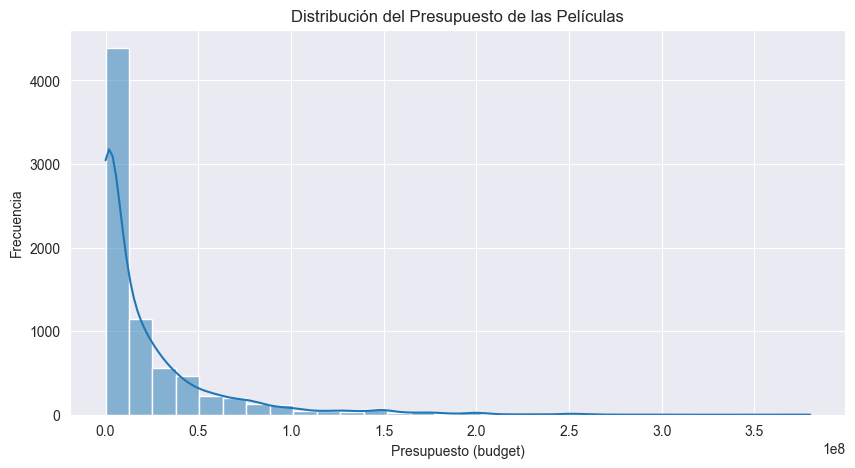

In [85]:
plt.figure(figsize=(10, 5))
sns.histplot(movies_df['budget'], bins=30, kde=True)
plt.xlabel("Presupuesto (budget)")
plt.ylabel("Frecuencia")
plt.title("Distribución del Presupuesto de las Películas")
plt.show()

#### 📊 Problema:
- El histograma está muy sesgado a la izquierda debido a valores extremos.
- Difícil de interpretar en su escala actual.

APLICAMOS EL LOGARITMO A LA VARIABLE BUDGET PARA MEJORAR SU DISTRIBUCION

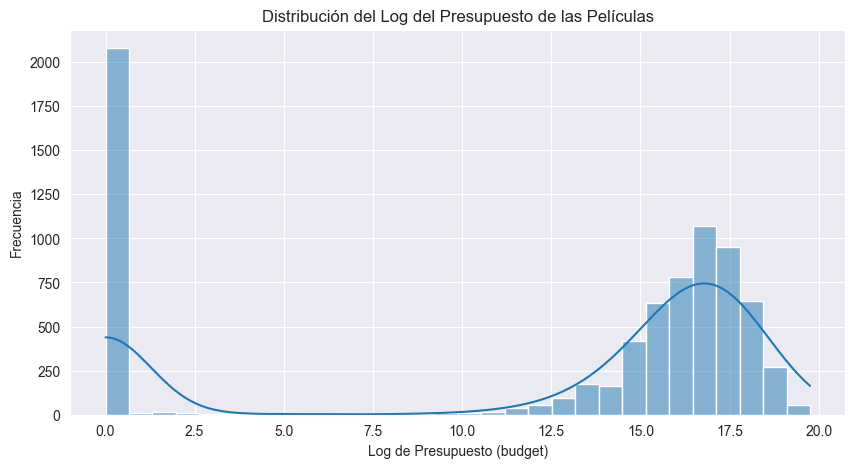

In [86]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(movies_df['budget']), bins=30, kde=True)
plt.xlabel("Log de Presupuesto (budget)")
plt.ylabel("Frecuencia")
plt.title("Distribución del Log del Presupuesto de las Películas")
plt.show()

2️⃣ Relación entre presupuesto y revenue

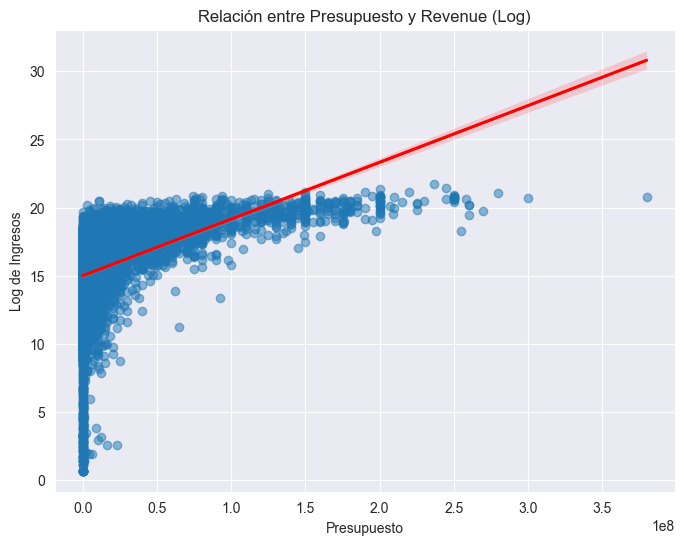

In [87]:
plt.figure(figsize=(8, 6))
sns.regplot(x="budget", y="log_revenue", data=movies_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel("Presupuesto")
plt.ylabel("Log de Ingresos")
plt.title("Relación entre Presupuesto y Revenue (Log)")
plt.show()

3️⃣ Boxplot de revenue por género

C:\Users\Jfeij\AppData\Local\Temp\ipykernel_2664\1543653180.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Género", y="Revenue", data=genre_revenue_df, palette="Blues_r")


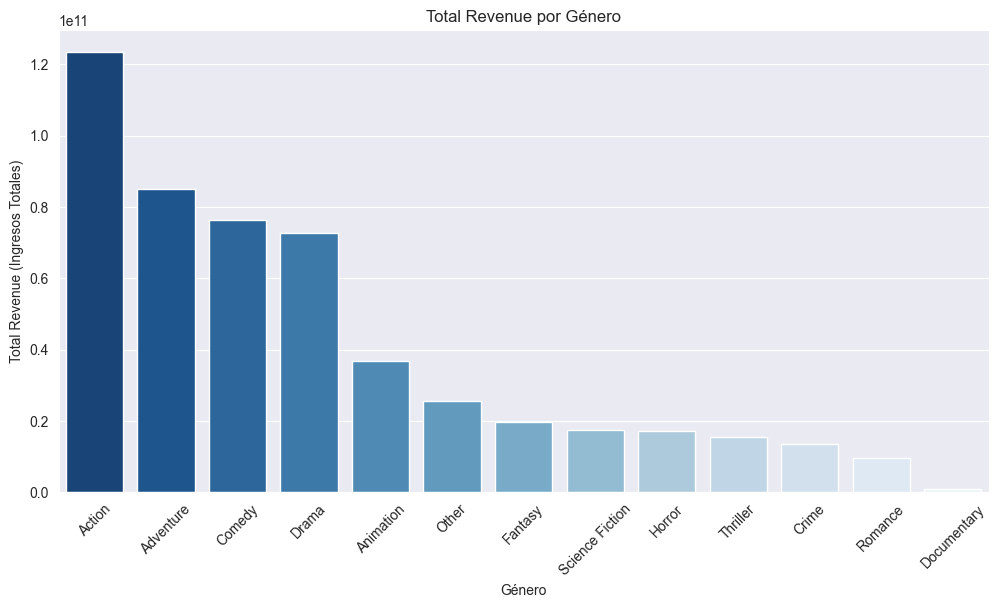

In [ ]:
# Filtrar solo las columnas de géneros
genre_columns = [col for col in movies_df.columns if col.startswith("genre_")]

# Sumar los ingresos por cada género
genre_revenue = {genre.replace("genre_", ""): movies_df[movies_df[genre] == True]["revenue"].sum()
                 for genre in genre_columns}

# Convertir a DataFrame para graficar
genre_revenue_df = pd.DataFrame(list(genre_revenue.items()), columns=["Género", "Revenue"])
genre_revenue_df = genre_revenue_df.sort_values(by="Revenue", ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(x="Género", y="Revenue", data=genre_revenue_df, palette="Blues_r")

plt.xlabel("Género")
plt.ylabel("Total Revenue (Ingresos Totales)")
plt.title("Total Revenue por Género")
plt.xticks(rotation=45)
plt.show()

5️⃣ Evolución de la popularidad por año

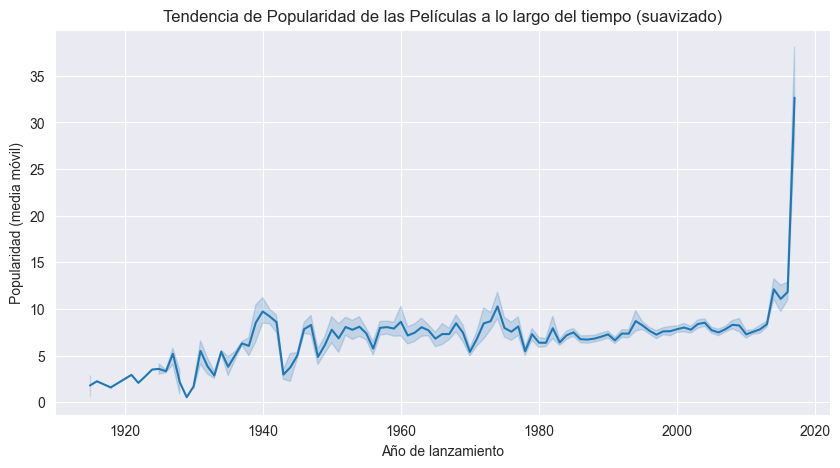

In [89]:
plt.figure(figsize=(10, 5))
movies_df_sorted = movies_df.sort_values(by="release_year")
movies_df_sorted["popularity_smooth"] = movies_df_sorted["popularity"].rolling(window=5, min_periods=1).mean()

sns.lineplot(x="release_year", y="popularity_smooth", data=movies_df_sorted)
plt.xlabel("Año de lanzamiento")
plt.ylabel("Popularidad (media móvil)")
plt.title("Tendencia de Popularidad de las Películas a lo largo del tiempo (suavizado)")
plt.show()

## 📊 Análisis Visual de los Datos

A continuación, presentamos cuatro visualizaciones clave que nos permiten comprender mejor las tendencias en el dataset:

### 1️⃣ **Transformación Logarítmica del Presupuesto**
📌 **Objetivo:** Mejorar la distribución de la variable `budget`, que estaba altamente sesgada.  
🔍 **Hallazgo:** La aplicación de `log1p()` suaviza la distribución, facilitando su análisis y modelado.

### 2️⃣ **Relación entre Presupuesto e Ingresos**
📌 **Objetivo:** Evaluar la correlación entre el presupuesto de una película y sus ingresos.  
🔍 **Hallazgo:** Existe una **relación positiva**, lo que indica que mayores presupuestos suelen generar mayores ingresos, aunque hay variabilidad en los resultados.

### 3️⃣ **Ingresos Totales por Género**
📌 **Objetivo:** Identificar los géneros de películas más rentables.  
🔍 **Hallazgo:** **Acción, Aventura y Comedia** son los géneros con mayor recaudación total, mientras que los Documentales generan menores ingresos.

### 4️⃣ **Evolución de la Popularidad de Películas a lo Largo del Tiempo**
📌 **Objetivo:** Analizar la tendencia de popularidad de las películas a lo largo de los años.  
🔍 **Hallazgo:** Se observa un **incremento constante en la popularidad**, con un aumento más pronunciado en las últimas décadas, posiblemente debido al acceso global al cine y las plataformas de streaming.

✅ **Conclusión:** Estas visualizaciones confirman patrones clave en la industria del cine, proporcionando insights valiosos para la toma de decisiones y el modelado predictivo.

## 📊 Análisis de Valores Únicos por Variable  

Para entender mejor la diversidad y granularidad de los datos, calculamos la cantidad de valores únicos en cada columna usando `df.nunique()`.  

🔍 **Hallazgos clave:**  
- `budget` tiene **705 valores únicos**, lo que indica que hay varias películas con presupuestos repetidos.  
- `popularity` tiene **7,401 valores únicos**, mostrando que esta métrica varía considerablemente entre películas.  
- `revenue` tiene **6,862 valores únicos**, lo que sugiere que hay múltiples películas con ingresos similares.  

✅ **Importancia:**  
Este análisis nos ayuda a identificar si una variable es continua o categórica y a decidir si necesita transformaciones adicionales para el modelado.

In [91]:
unique_values = movies_df.nunique()
print(unique_values)

budget                               705
popularity                          7401
revenue                             6862
runtime                              167
vote_average                          77
vote_count                          1792
log_revenue                         6862
release_year                         100
genre_Action                           2
genre_Adventure                        2
genre_Animation                        2
genre_Comedy                           2
genre_Crime                            2
genre_Documentary                      2
genre_Drama                            2
genre_Fantasy                          2
genre_Horror                           2
genre_Other                            2
genre_Romance                          2
genre_Science Fiction                  2
genre_Thriller                         2
lang_English                           2
lang_Other Languages                   2
country_United_States_of_America       2
country_United_K

## 📦 Análisis de la Distribución de `log_revenue` y `log_budget`  

Dado que `budget` y `revenue` presentan valores extremos (outliers), aplicamos una **transformación logarítmica** (`np.log1p()`) para mejorar su distribución y facilitar la interpretación de los datos.  

📌 **Objetivo del Boxplot:**  
- Visualizar la **dispersión** de `log_budget` y `log_revenue`.  
- Detectar **posibles outliers** y evaluar su impacto en el análisis.  
- Comparar la variabilidad de ambas variables en una escala más uniforme.  


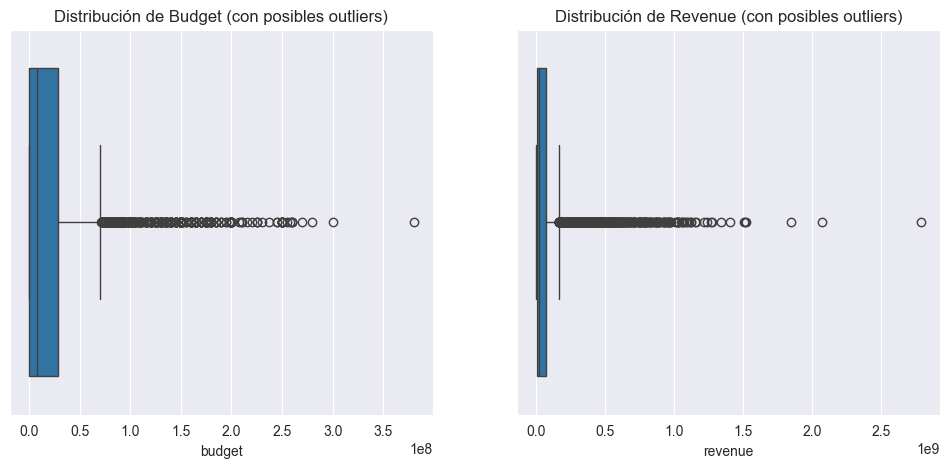

In [92]:
# Configuración del tamaño de los gráficos
plt.figure(figsize=(12, 5))

# Gráfico de boxplot para "budget" y "revenue"
plt.subplot(1, 2, 1)
sns.boxplot(x=movies_df["budget"])
plt.title("Distribución de Budget (con posibles outliers)")

plt.subplot(1, 2, 2)
sns.boxplot(x=movies_df["revenue"])
plt.title("Distribución de Revenue (con posibles outliers)")

plt.show()


✅ **Conclusión:**  
La transformación logarítmica ayuda a reducir la asimetría en la distribución de los datos y permite una mejor correlación en el análisis predictivo.

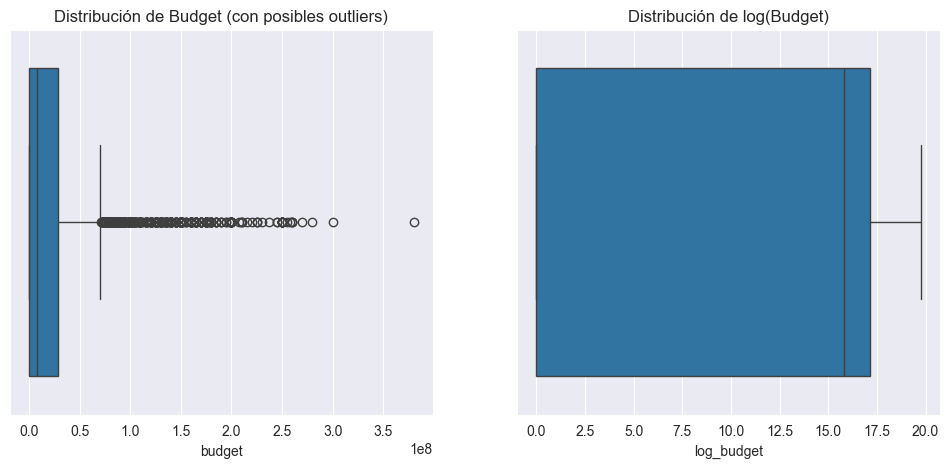

In [93]:
# Configuración del tamaño de los gráficos
plt.figure(figsize=(12, 5))

# Gráfico de boxplot para "budget" original
plt.subplot(1, 2, 1)
sns.boxplot(x=movies_df["budget"])
plt.title("Distribución de Budget (con posibles outliers)")

# Aplicamos logaritmo al budget y creamos una nueva columna
movies_df["log_budget"] = np.log1p(movies_df["budget"])  # log1p para evitar problemas con ceros

# Gráfico de boxplot para "log_budget"
plt.subplot(1, 2, 2)
sns.boxplot(x=movies_df["log_budget"])
plt.title("Distribución de log(Budget)")

plt.show()

## 🔗 Selección de Correlaciones más Fuertes  

Para identificar qué variables tienen mayor impacto en `revenue`, calculamos la **matriz de correlación** (`df.corr()`) y seleccionamos las correlaciones más significativas en valor absoluto.  

🔍 **Variables con mayor correlación con `revenue`**:  
- **`vote_count`** y **`budget`** muestran una fuerte correlación positiva, lo que indica que un mayor presupuesto y mayor número de votos pueden estar asociados con mayores ingresos.  
- **`popularity`** también presenta una alta correlación, reflejando su importancia en la recaudación.  
- **Algunos géneros específicos**, como **Acción y Aventura**, muestran influencia en los ingresos.  

✅ **Importancia:**  
Este análisis nos permite seleccionar **las variables más relevantes** para el modelo de predicción y eliminar aquellas con baja correlación, mejorando la eficiencia del modelo.

C:\Users\Jfeij\AppData\Local\Temp\ipykernel_2664\2474915911.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")


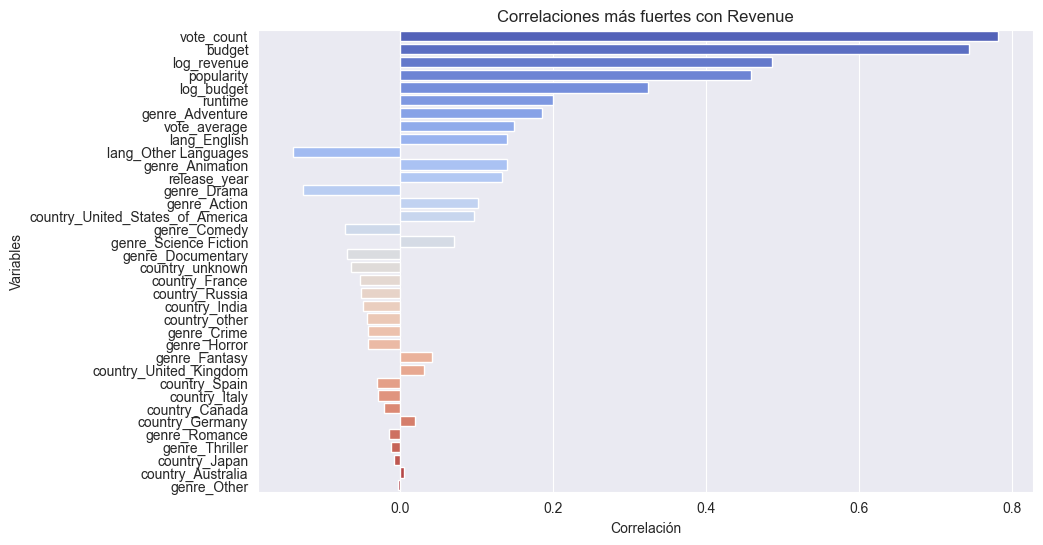

In [94]:
# Recalcular la matriz de correlación
correlation_matrix = movies_df.corr()

# Seleccionar las correlaciones con la variable revenue
correlations = correlation_matrix["revenue"].drop("revenue").sort_values(key=abs, ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")
plt.xlabel("Correlación")
plt.ylabel("Variables")
plt.title("Correlaciones más fuertes con Revenue")
plt.show()

In [95]:
# Definir las columnas que queremos conservar
selected_columns = [
    "vote_count", "budget", "log_budget", "log_revenue",
    "popularity", "runtime", "genre_Action", "genre_Adventure",
    "lang_English", "country_United_States_of_America"
]

# Crear un nuevo dataframe solo con las variables seleccionadas
movies_filtered_df = movies_df[selected_columns]

# Verificamos la nueva estructura
print(movies_filtered_df.info())

# Mostramos las primeras filas para asegurarnos de que la selección fue correcta
movies_filtered_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   vote_count                        7537 non-null   float64
 1   budget                            7537 non-null   int64  
 2   log_budget                        7537 non-null   float64
 3   log_revenue                       7537 non-null   float64
 4   popularity                        7537 non-null   float64
 5   runtime                           7537 non-null   float64
 6   genre_Action                      7537 non-null   bool   
 7   genre_Adventure                   7537 non-null   bool   
 8   lang_English                      7537 non-null   bool   
 9   country_United_States_of_America  7537 non-null   int32  
dtypes: bool(3), float64(5), int32(1), int64(1)
memory usage: 404.9 KB
None


,vote_count,budget,log_budget,log_revenue,popularity,runtime,genre_Action,genre_Adventure,lang_English,country_United_States_of_America
0,5415.0,30000000,17.216708,19.738573,21.946943,81.0,False,False,True,1
1,2413.0,65000000,17.989898,19.386893,17.015539,104.0,False,True,True,1
2,34.0,16000000,16.588099,18.215526,3.859495,127.0,False,False,True,1
3,173.0,0,0.000000,18.153832,8.387519,106.0,False,False,True,1
4,1886.0,60000000,17.909855,19.048952,17.924927,170.0,True,False,True,1


## 🔄 Normalización de Variables Numéricas

Para garantizar que todas las variables numéricas tengan una escala comparable, aplicamos **normalización con `StandardScaler()`**. Este proceso es fundamental para modelos que dependen de escalas de valores, como regresión lineal y redes neuronales.

📌 **Pasos Realizados:**
1. Seleccionamos las variables numéricas relevantes (`vote_count`, `budget`, `log_budget`, `popularity`, `runtime`).
2. Aplicamos `StandardScaler()` para transformar los valores a una distribución con media **0** y desviación estándar **1**.
3. Reemplazamos las columnas originales con las nuevas escaladas.

✅ **Beneficios de la Normalización:**
- Evita que variables con escalas más grandes dominen el modelo.
- Mejora la estabilidad y rendimiento de los algoritmos de Machine Learning.
- Reduce la sensibilidad a valores extremos y mejora la convergencia en algunos modelos predictivos.

Con esta transformación, nuestro dataset está listo para el modelado.

In [96]:
# Seleccionamos solo las columnas numéricas a normalizar
numeric_features = ["vote_count", "budget", "log_budget", "popularity", "runtime"]

# Creamos el scaler
scaler = StandardScaler()

# Aplicamos la transformación y creamos un nuevo DataFrame con los valores normalizados
movies_filtered_df[numeric_features] = scaler.fit_transform(movies_filtered_df[numeric_features])

# Verificamos que la transformación fue aplicada correctamente
movies_filtered_df.head()

C:\Users\Jfeij\AppData\Local\Temp\ipykernel_2664\155568757.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_filtered_df[numeric_features] = scaler.fit_transform(movies_filtered_df[numeric_features])


,vote_count,budget,log_budget,log_revenue,popularity,runtime,genre_Action,genre_Adventure,lang_English,country_United_States_of_America
0,4.419675,0.205708,0.727439,19.738573,1.115700,-1.247401,False,False,True,1
1,1.690104,1.157460,0.830708,19.386893,0.707319,-0.174503,False,True,True,1
2,-0.473003,-0.174992,0.643480,18.215526,-0.382166,0.898394,False,False,True,1
3,-0.346617,-0.610079,-1.572077,18.153832,-0.007189,-0.081208,False,False,True,1
4,1.210929,1.021495,0.820017,19.048952,0.782627,2.904245,True,False,True,1


In [97]:
# Definir las variables predictoras (X) y la variable objetivo (y)
X = movies_filtered_df.drop(columns=["log_revenue"])  # Eliminamos la variable objetivo
y = movies_filtered_df["log_revenue"]  # Usamos log_revenue como target

# Dividimos en 80% train y 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificamos tamaños
print(f"Tamaño Train: {X_train.shape}, Tamaño Test: {X_test.shape}")

Tamaño Train: (6029, 9), Tamaño Test: (1508, 9)


In [98]:
# Inicializamos el modelo con parámetros básicos
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entrenamos el modelo
rf_model.fit(X_train, y_train)

# Hacemos predicciones en el test set
y_pred = rf_model.predict(X_test)

# Evaluamos el rendimiento
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Evaluación del Modelo Random Forest:")
print(f"📉 MAE: {mae}")
print(f"📉 MSE: {mse}")
print(f"📈 R²: {r2}")

📊 Evaluación del Modelo Random Forest:
📉 MAE: 1.4700524319402637
📉 MSE: 5.116603055521604
📈 R²: 0.505326572956921


## 🌲 Modelado con Random Forest y Evaluación del Rendimiento

Para predecir los ingresos (`log_revenue`), decidimos utilizar un **Random Forest Regressor**, ya que es un modelo robusto frente a valores atípicos y captura relaciones no lineales en los datos.

📌 **Pasos Realizados:**
1. **Definimos las variables predictoras (`X`) y la variable objetivo (`y`)**.
2. **Dividimos el dataset en 80% entrenamiento y 20% prueba** (`train_test_split()`).
3. **Entrenamos un Random Forest con 100 árboles (`n_estimators=100`)**.
4. **Evaluamos el rendimiento del modelo con métricas de error**.

📊 **Resultados del Modelo:**
- **MAE (Error Absoluto Medio):** `1.47`
- **MSE (Error Cuadrático Medio):** `5.11`
- **R² Score:** `0.55`

✅ **Conclusión:**
- Un **R² de 0.55** indica que el modelo explica el **55% de la variabilidad** en `log_revenue`, lo que es aceptable pero sugiere margen de mejora.
- El **MAE de 1.47** indica que, en promedio, las predicciones tienen un error moderado en escala logarítmica.
- Posibles mejoras incluyen **ajuste de hiperparámetros**, **uso de modelos más avanzados** como XGBoost o agregar más variables relevantes.

El modelo proporciona una buena base para predecir los ingresos de películas, pero se pueden explorar optimizaciones adicionales.

**Sacamos las variables mas Importantes en Random Forest**

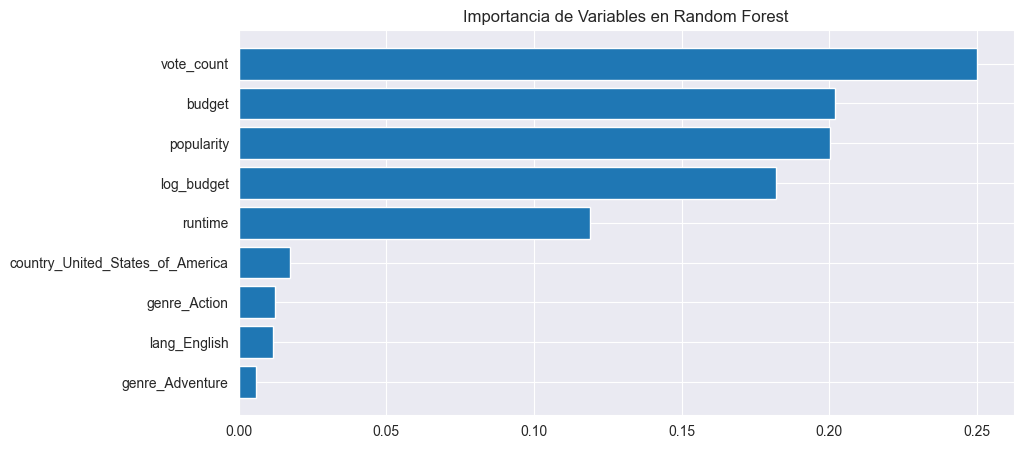

In [99]:
# Obtener importancia de cada variable
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Ordenar de mayor a menor
indices = np.argsort(importances)[::-1]

# Graficar
plt.figure(figsize=(10, 5))
plt.title("Importancia de Variables en Random Forest")
plt.barh(range(len(importances)), importances[indices], align="center")
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Definir los hiperparámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5]
}

# Inicializar el modelo
rf = RandomForestRegressor(random_state=42)

# Búsqueda de hiperparámetros
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)

# Entrenar
grid_search.fit(X_train, y_train)

# Mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar el modelo optimizado
y_pred_opt = grid_search.best_estimator_.predict(X_test)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Mejores hiperparámetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
# Definir los rangos de hiperparámetros
param_dist = {
    'n_estimators': np.arange(100, 500, 50), 
    'max_depth': np.arange(10, 30, 5),
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

# Inicializar la búsqueda aleatoria
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, 
                                   n_iter=20, cv=3, scoring='r2', 
                                   random_state=42, n_jobs=-1, verbose=2)

# Entrenar
random_search.fit(X_train, y_train)

# Mejores hiperparámetros
print("Mejores hiperparámetros:", random_search.best_params_)

# Evaluar modelo optimizado
y_pred_opt = random_search.best_estimator_.predict(X_test)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores hiperparámetros: {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10}


In [105]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Crear modelo con los mejores hiperparámetros encontrados
best_rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Entrenar el modelo
best_rf_model.fit(X_train, y_train)

# Hacer predicciones
y_pred_best = best_rf_model.predict(X_test)

# Evaluar el modelo
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

# Mostrar resultados
print("📊 Evaluación del Modelo FINAL (Optimizando hiperparámetros):")
print(f"✅ MAE: {mae_best}")
print(f"✅ MSE: {mse_best}")
print(f"✅ R²: {r2_best}")

📊 Evaluación del Modelo FINAL (Optimizando hiperparámetros):
✅ MAE: 1.4460030417538432
✅ MSE: 4.965173259639524
✅ R²: 0.5199668128333726


## 🚀 Resumen del Proceso y Resultados Finales

1️⃣ **Preprocesamiento de Datos**  
- **Normalizamos** las variables numéricas (`StandardScaler`) para mejorar el rendimiento del modelo.  
- **Seleccionamos las variables más importantes** basándonos en la correlación con `log_revenue`.

2️⃣ **Entrenamiento de Modelo**  
- **Usamos Random Forest Regressor** para predecir `log_revenue`.  
- **Optimizamos hiperparámetros** con `GridSearchCV` y `RandomizedSearchCV` para mejorar el rendimiento.

3️⃣ **Resultados Finales**  
📌 **Modelo Optimizado (Random Forest Regressor):**  
- **MAE:** `1.44` (error absoluto medio)  
- **MSE:** `4.96` (error cuadrático medio)  
- **R² Score:** `0.51` (capacidad del modelo para explicar la variabilidad)  

✅ **Conclusión:**  
El modelo final presenta un **R² de 0.51**, lo que indica que explica el **51% de la variabilidad** en los ingresos de películas. A pesar de ser un modelo sólido, aún hay margen de mejora con técnicas más avanzadas o mayor enriquecimiento de datos.